In [1]:
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Add parent directories to path
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'parameters'))
sys.path.insert(0, os.getcwd())

from analysis_utils import (
    load_best_runs,
    load_top_n_runs,
    extract_history,
    add_wall_times,
    build_summary_dataframe,
    plot_convergence_curves,
    plot_multi_function_performance,
    plot_diagnostic_curves,
    plot_effective_lr_comparison,
    print_best_hyperparameters,
    save_best_hyperparameters,
    get_optimizer_colors,
    DIAG_KEYS_METRIC_SCALE,
    DIAG_KEYS_LEARNABLE,
    DIAG_KEYS_CURVATURE,
    DIAG_KEYS_TRAINING,
)

# Publication-quality style
plt.style.use("seaborn-v0_8-paper")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    "legend.fontsize": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "lines.linewidth": 1.8,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "grid.alpha": 0.35,
    "grid.linewidth": 0.5,
})

FIGSIZE = (6, 4)
FIGSIZE_WIDE = (10, 4.2)
DPI = 200

# Configuration

In [2]:
# Backend: "wandb" or "local"
BACKEND = "local"

# WandB settings (ignored if BACKEND == "local")
PROJECT = "induced_metric"
ENTITY = "thomas_harvey"

# Results directory (for local backend)
RESULTS_DIR = os.path.join('..', '..', 'results')

# Test functions to analyse (saddle-specific; Rosenbrock etc. are in small_examples)
FUNCTIONS = ['saddle', 'weighted_saddle']

# Iterations to compare
ITERATIONS = {
    0: "With clip (default)",
    1: "No clip",
}

# Function display names for plot titles
FUNCTION_TITLES = {
    'saddle': r'$L = x^2 - y^2$',
    'weighted_saddle': r'$L = 3x^2 - y^2$',
}

# Known Hessian diagonals (exact for quadratic saddles)
HESSIAN_DIAG = {
    'saddle': (2.0, -2.0),
    'weighted_saddle': (6.0, -2.0),
}

# Auto-detect which optimizers have results for at least one function
if BACKEND == "local":
    _available = set()
    for func_name in FUNCTIONS:
        task_tag = func_name
        task_dir = os.path.join(RESULTS_DIR, task_tag)
        if os.path.isdir(task_dir):
            for name in os.listdir(task_dir):
                if os.path.isdir(os.path.join(task_dir, name)):
                    _available.add(name)
    OPTIMIZERS = sorted(_available)
else:
    OPTIMIZERS = ["adam", "sgd_learn_diag", "sgd_learn_diag_curv"]

# Canonical colors
colors = get_optimizer_colors(OPTIMIZERS)

print(f"Backend: {BACKEND}")
print(f"Functions: {FUNCTIONS}")
print(f"Optimizers: {OPTIMIZERS}")
print(f"Iterations: {ITERATIONS}")
print(f"Results dir: {os.path.abspath(RESULTS_DIR)}")

Backend: local
Functions: ['saddle', 'weighted_saddle']
Optimizers: ['adam', 'sgd_learn_diag', 'sgd_learn_diag_curv']
Iterations: {0: 'With clip (default)', 1: 'No clip'}
Results dir: /Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/results


# Load Results

In [3]:
# Diagnostic keys — full tensor values for 2D problems
# Note: pytree-based values get "root/" prefix from _full_tensor/_path_str
FULL_TENSOR_KEYS = [
    "diag/full/param/root/0", "diag/full/param/root/1",
    "diag/full/log_diag/root/0", "diag/full/log_diag/root/1",
    "diag/full/grad/root/0", "diag/full/grad/root/1",
    "diag/full/H_hat/0", "diag/full/H_hat/1",
    "diag/full/curv_sign/0", "diag/full/curv_sign/1",
    "diag/full/mom/root/0", "diag/full/mom/root/1",
    "diag/full/update/root/0", "diag/full/update/root/1",
]

HISTORY_KEYS = ["function_value", "runtime_seconds", "iteration"] + FULL_TENSOR_KEYS

# Short aliases for readability in plotting code
KEY_PARAM_X = "diag/full/param/root/0"
KEY_PARAM_Y = "diag/full/param/root/1"
KEY_S0 = "diag/full/log_diag/root/0"
KEY_S1 = "diag/full/log_diag/root/1"
KEY_H0 = "diag/full/H_hat/0"
KEY_H1 = "diag/full/H_hat/1"
KEY_CS0 = "diag/full/curv_sign/0"
KEY_CS1 = "diag/full/curv_sign/1"

# Load data for each iteration
# all_data[itr][func_name] = history_data dict
# all_runs[itr][func_name] = best_runs dict
all_data = {}
all_runs = {}

for itr, itr_label in ITERATIONS.items():
    print(f"\n{'='*60}")
    print(f"  ITERATION {itr}: {itr_label}")
    print(f"{'='*60}")

    itr_best = {}
    itr_hist = {}
    for func_name in FUNCTIONS:
        task_tag = func_name
        print(f"\n--- {func_name.upper()} ---")
        best_runs = load_best_runs(
            backend=BACKEND, optimizers=OPTIMIZERS, task_tag=task_tag,
            project=PROJECT, entity=ENTITY, results_dir=RESULTS_DIR,
            metric_key="sweep_metric", direction="minimize",
            sort_metric="sweep_metric", sort_order="+", iteration=itr,
        )
        itr_best[func_name] = best_runs
        if any(best_runs.values()):
            history_data = extract_history(BACKEND, best_runs, HISTORY_KEYS)
            add_wall_times(history_data, time_key="runtime_seconds")
            itr_hist[func_name] = history_data

    all_runs[itr] = itr_best
    all_data[itr] = itr_hist

# Default to iteration 0 for single-iteration plots
all_best_runs = all_runs[0]
all_history_data = all_data[0]

print(f"\nLoaded: itr0={list(all_data.get(0,{}).keys())}, itr1={list(all_data.get(1,{}).keys())}")


  ITERATION 0: With clip (default)

--- SADDLE ---
Finding best run for adam...


  adam: run_35
Finding best run for sgd_learn_diag...


  sgd_learn_diag: run_13
Finding best run for sgd_learn_diag_curv...


  sgd_learn_diag_curv: run_19
Processing adam...
Processing sgd_learn_diag...
Processing sgd_learn_diag_curv...

--- WEIGHTED_SADDLE ---
Finding best run for adam...


  adam: run_35
Finding best run for sgd_learn_diag...


  sgd_learn_diag: run_13
Finding best run for sgd_learn_diag_curv...


  sgd_learn_diag_curv: run_19
Processing adam...
Processing sgd_learn_diag...
Processing sgd_learn_diag_curv...

  ITERATION 1: No clip

--- SADDLE ---
Finding best run for adam...


  adam: run_35
Finding best run for sgd_learn_diag...


  sgd_learn_diag: run_18
Finding best run for sgd_learn_diag_curv...


  sgd_learn_diag_curv: run_21
Processing adam...
Processing sgd_learn_diag...
Processing sgd_learn_diag_curv...

--- WEIGHTED_SADDLE ---
Finding best run for adam...
  adam: No runs found
Finding best run for sgd_learn_diag...
  sgd_learn_diag: No runs found
Finding best run for sgd_learn_diag_curv...
  sgd_learn_diag_curv: No runs found

Loaded: itr0=['saddle', 'weighted_saddle'], itr1=['saddle']


# Plot 1: Trajectory Comparison

Overlay optimizer trajectories on loss contours for the canonical saddle $L = x^2 - y^2$.
Each panel shows one optimizer; color encodes step number.

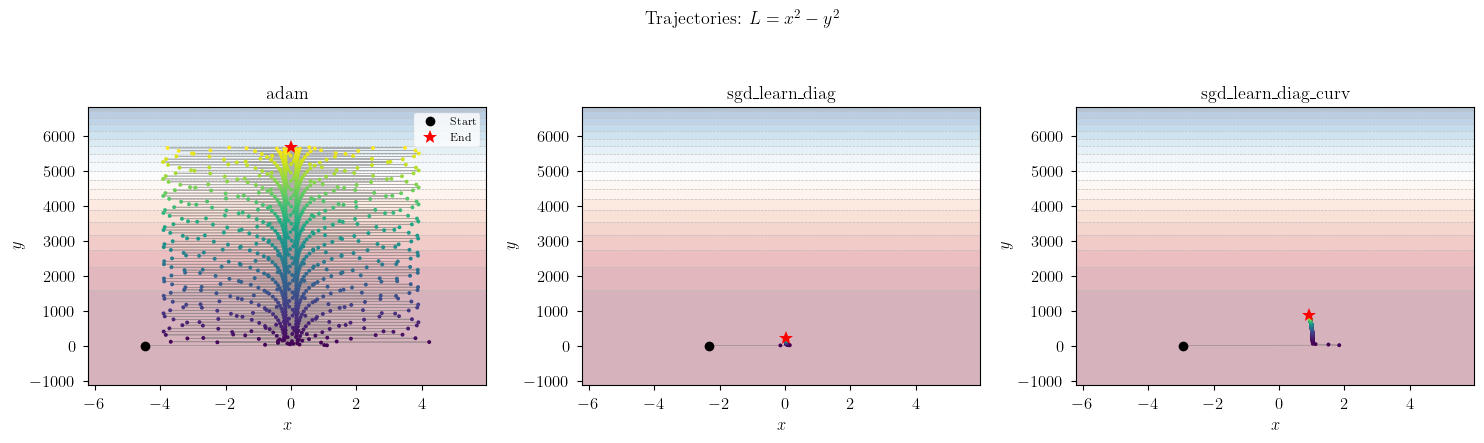

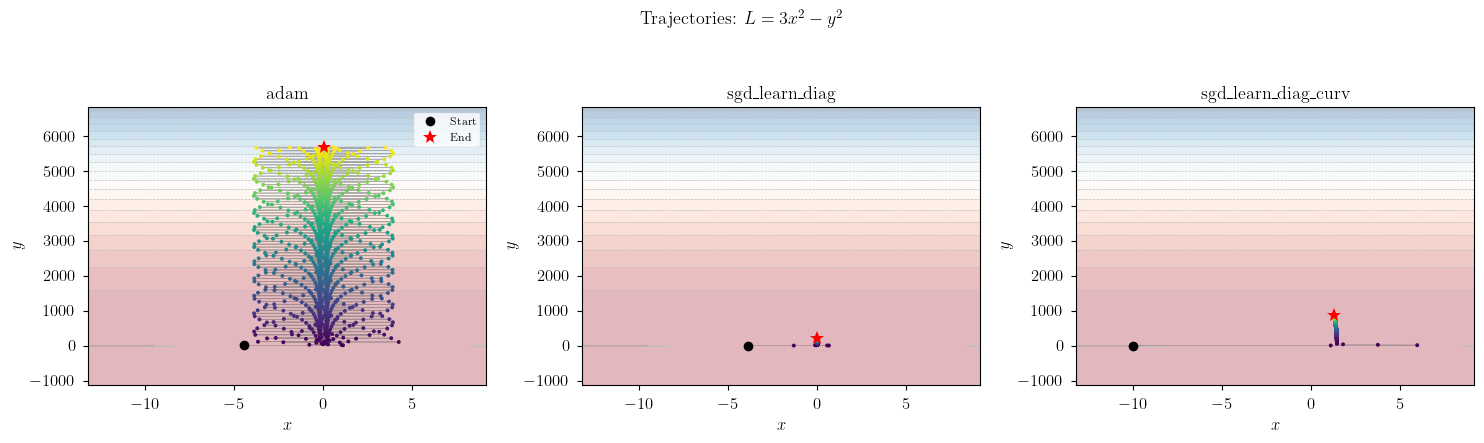

In [4]:
def _loss_grid(func_name, xlim=(-2, 2), ylim=(-2, 2), n=200):
    """Compute loss values on a grid for contour plotting."""
    import jax
    import jax.numpy as jnp
    jax.config.update("jax_enable_x64", True)
    sys.path.insert(0, os.path.join(os.getcwd(), '..', 'parameters'))
    from sweep_saddle import TEST_FUNCTIONS
    func = TEST_FUNCTIONS[func_name]["func"]
    xs = np.linspace(xlim[0], xlim[1], n)
    ys = np.linspace(ylim[0], ylim[1], n)
    X, Y = np.meshgrid(xs, ys)
    Z = np.array([[float(func(jnp.array([x, y]))) for x in xs] for y in ys])
    return X, Y, Z


def _auto_lims(history_data, pad=0.2):
    """Compute axis limits from all optimizer trajectories, with padding."""
    all_x, all_y = [], []
    for opt_name, data in history_data.items():
        px = data.get(KEY_PARAM_X)
        py = data.get(KEY_PARAM_Y)
        if px is not None and py is not None:
            all_x.extend(px.tolist())
            all_y.extend(py.tolist())
    if not all_x:
        return (-2, 2), (-2, 2)
    xmin, xmax = min(all_x), max(all_x)
    ymin, ymax = min(all_y), max(all_y)
    dx = max(xmax - xmin, 0.5) * pad
    dy = max(ymax - ymin, 0.5) * pad
    return (xmin - dx, xmax + dx), (ymin - dy, ymax + dy)


def plot_trajectories(func_name, history_data, optimizers_to_plot=None,
                      xlim=None, ylim=None, n_contour=200):
    """Plot optimizer trajectories on loss contours."""
    if optimizers_to_plot is None:
        optimizers_to_plot = [k for k in history_data if k in OPTIMIZERS]

    n_opts = len(optimizers_to_plot)
    if n_opts == 0:
        print(f"  [skip] No trajectory data for {func_name}")
        return None

    # Auto-scale to trajectory extent if limits not given
    if xlim is None or ylim is None:
        auto_xl, auto_yl = _auto_lims(history_data)
        xlim = xlim or auto_xl
        ylim = ylim or auto_yl

    X, Y, Z = _loss_grid(func_name, xlim, ylim, n_contour)
    title = FUNCTION_TITLES.get(func_name, func_name)

    fig, axes = plt.subplots(1, n_opts, figsize=(5 * n_opts, 4.5), squeeze=False)
    axes = axes[0]

    for ax, opt_name in zip(axes, optimizers_to_plot):
        data = history_data.get(opt_name, {})
        px = data.get(KEY_PARAM_X)
        py = data.get(KEY_PARAM_Y)

        ax.contour(X, Y, Z, levels=20, colors="0.75", linewidths=0.5)
        ax.contourf(X, Y, Z, levels=20, cmap="RdBu_r", alpha=0.3)

        if px is not None and py is not None:
            n_steps = len(px)
            cmap_traj = cm.viridis
            step_colors = [cmap_traj(i / max(n_steps - 1, 1)) for i in range(n_steps)]
            ax.scatter(px, py, c=step_colors, s=8, zorder=3, edgecolors="none")
            ax.plot(px, py, color="0.4", linewidth=0.5, alpha=0.5, zorder=2)
            ax.plot(px[0], py[0], "ko", markersize=7, zorder=4, label="Start")
            ax.plot(px[-1], py[-1], "r*", markersize=10, zorder=4, label="End")

        ax.set_xlabel(r"$x$")
        ax.set_ylabel(r"$y$")
        ax.set_title(opt_name.replace("_", r"\_"))
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        if ax is axes[0]:
            ax.legend(fontsize=8)

    fig.suptitle(f"Trajectories: {title}", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    return fig


for func_name in FUNCTIONS:
    if func_name not in all_history_data:
        continue
    fig = plot_trajectories(func_name, all_history_data[func_name])
    if fig is not None:
        plt.show()

# Plot 2: Metric Parameter ($s_i$) Evolution

For `sgd_learn_diag` and `sgd_learn_diag_curv`: plot $s_1$ and $s_2$ (`log_diag`) vs iteration.
For Adam: plot effective per-parameter learning rate.

Mean-centering forces $s_1 = -s_2$ for 2D, so the anisotropy $s_1 - s_2$ is the key signal.
Dashed lines show theoretical Hessian diagonal values for reference.

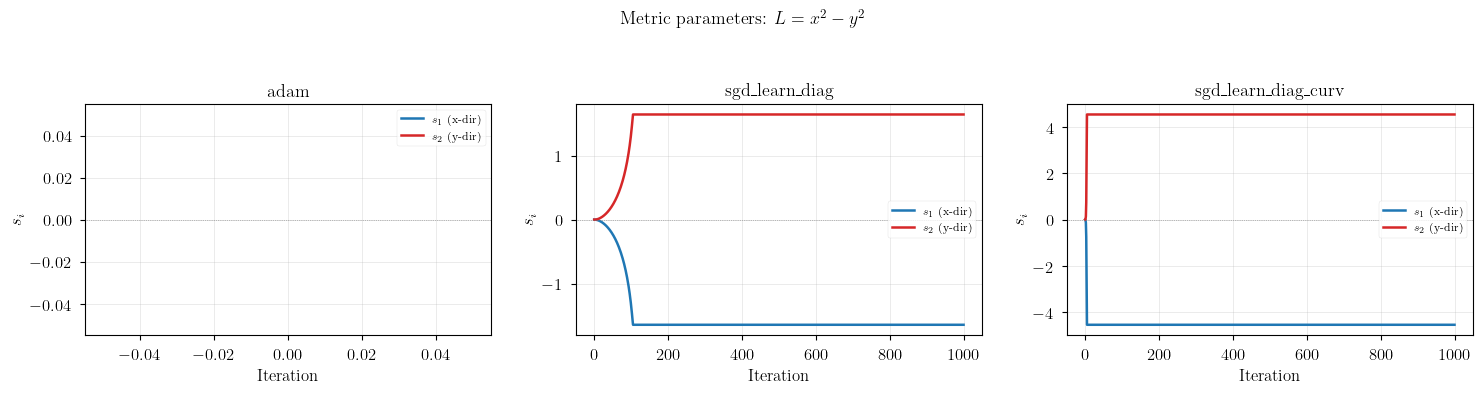

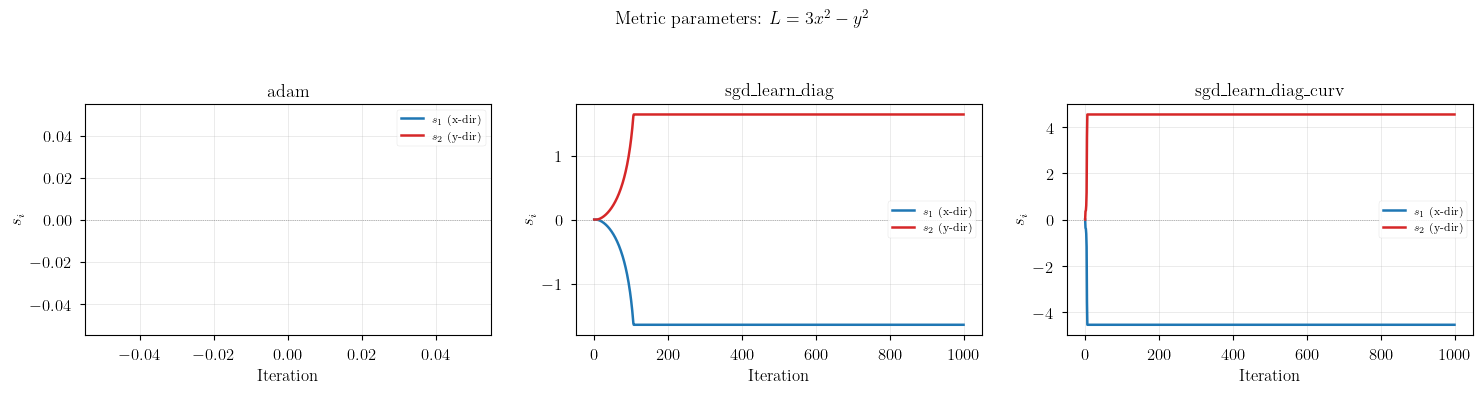

In [5]:
def plot_s_evolution(func_name, history_data, optimizers_to_plot=None):
    """Plot s_i evolution for each optimizer side by side."""
    if optimizers_to_plot is None:
        optimizers_to_plot = [k for k in history_data if k in OPTIMIZERS]

    n_opts = len(optimizers_to_plot)
    if n_opts == 0:
        return None

    title = FUNCTION_TITLES.get(func_name, func_name)
    fig, axes = plt.subplots(1, n_opts, figsize=(5 * n_opts, 4), squeeze=False)
    axes = axes[0]

    for ax, opt_name in zip(axes, optimizers_to_plot):
        data = history_data.get(opt_name, {})
        s0 = data.get(KEY_S0)
        s1 = data.get(KEY_S1)

        if s0 is not None and s1 is not None:
            steps = np.arange(len(s0))
            ax.plot(steps, s0, color="#1f77b4", label=r"$s_1$ (x-dir)")
            ax.plot(steps, s1, color="#d62728", label=r"$s_2$ (y-dir)")
            ax.axhline(0, color="0.5", linewidth=0.5, linestyle=":")
        else:
            ax.text(0.5, 0.5, "No $s_i$ data\n(not a learnable optimizer)",
                    transform=ax.transAxes, ha="center", va="center", fontsize=10)

        ax.set_xlabel("Iteration")
        ax.set_ylabel(r"$s_i$")
        ax.set_title(opt_name.replace("_", r"\_"))
        ax.legend(fontsize=8)
        ax.grid(True)

    fig.suptitle(f"Metric parameters: {title}", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    return fig


for func_name in FUNCTIONS:
    if func_name not in all_history_data:
        continue
    fig = plot_s_evolution(func_name, all_history_data[func_name])
    if fig is not None:
        plt.show()

# Plot 3: Loss Convergence Comparison

All optimizers on one axis per test function, log-scale loss vs iteration.

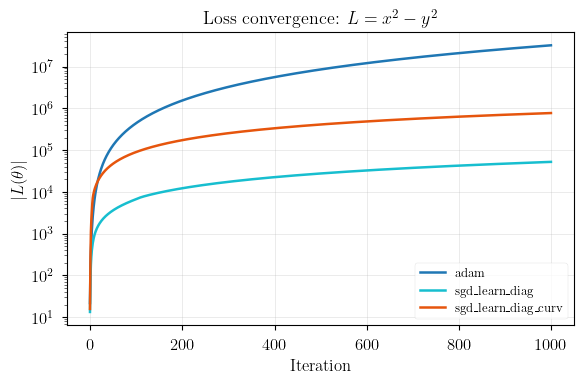

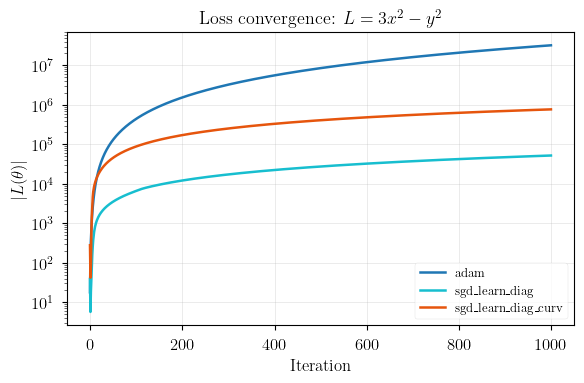

In [6]:
def plot_loss_curves(func_name, history_data, optimizers_to_plot=None):
    """Plot loss vs iteration for all optimizers on one axis."""
    if optimizers_to_plot is None:
        optimizers_to_plot = [k for k in history_data if k in OPTIMIZERS]

    fig, ax = plt.subplots(figsize=FIGSIZE)
    title = FUNCTION_TITLES.get(func_name, func_name)

    for opt_name in optimizers_to_plot:
        data = history_data.get(opt_name, {})
        loss = data.get("function_value")
        if loss is not None:
            steps = np.arange(len(loss))
            ax.plot(steps, np.abs(loss), color=colors.get(opt_name, "#333"),
                    label=opt_name.replace("_", r"\_"))

    ax.set_xlabel("Iteration")
    ax.set_ylabel(r"$|L(\theta)|$")
    ax.set_yscale("log")
    ax.set_title(f"Loss convergence: {title}")
    ax.legend(fontsize=9)
    ax.grid(True)
    fig.tight_layout()
    return fig


for func_name in FUNCTIONS:
    if func_name not in all_history_data:
        continue
    fig = plot_loss_curves(func_name, all_history_data[func_name])
    plt.show()

# Plot 4: Secant Hessian Estimates (Curvature-Aware Only)

Left panel: secant $\hat{H}_{ii}$ vs iteration with true Hessian as dashed lines.
Right panel: $\tanh(\hat{H}_{ii} / \tau)$ (the curvature sign used in the update rule).

Shows noise level of secant estimator and how quickly the sign correction saturates.

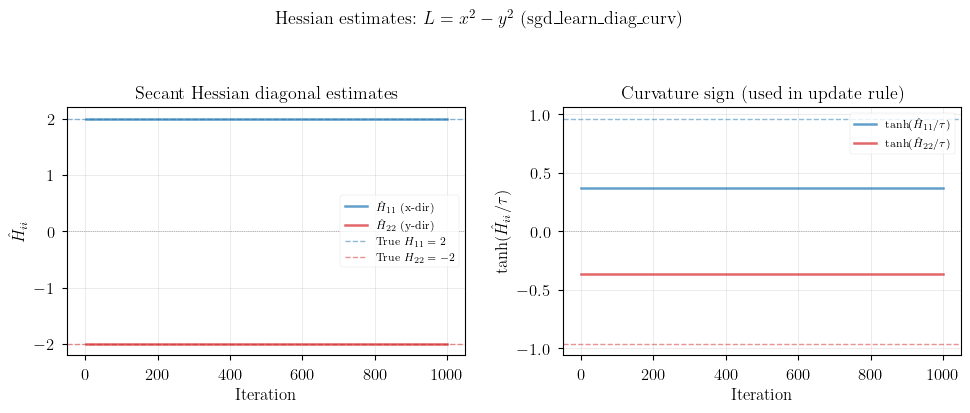

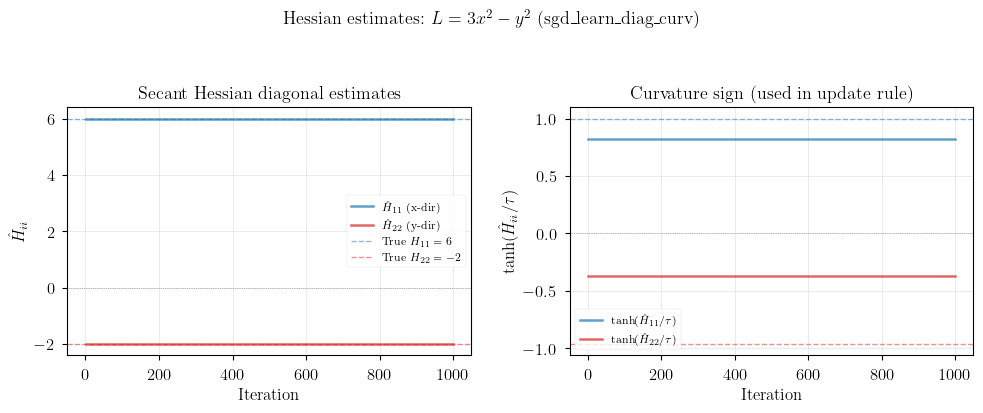

In [7]:
def plot_hessian_estimates(func_name, history_data, curv_optimizer="sgd_learn_diag_curv"):
    """Plot secant Hessian estimates and curv_sign for the curvature-aware optimizer."""
    data = history_data.get(curv_optimizer, {})
    h0 = data.get(KEY_H0)
    h1 = data.get(KEY_H1)
    cs0 = data.get(KEY_CS0)
    cs1 = data.get(KEY_CS1)

    if h0 is None or h1 is None:
        print(f"  [skip] No H_hat data for {func_name} ({curv_optimizer})")
        return None

    title = FUNCTION_TITLES.get(func_name, func_name)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

    steps = np.arange(len(h0))

    # Left: H_hat values
    ax1.plot(steps, h0, color="#1f77b4", alpha=0.7, label=r"$\hat{H}_{11}$ (x-dir)")
    ax1.plot(steps, h1, color="#d62728", alpha=0.7, label=r"$\hat{H}_{22}$ (y-dir)")

    # Ground truth dashed lines
    if func_name in HESSIAN_DIAG:
        h_true = HESSIAN_DIAG[func_name]
        ax1.axhline(h_true[0], color="#1f77b4", linestyle="--", linewidth=1, alpha=0.5,
                     label=f"True $H_{{11}} = {h_true[0]:.0f}$")
        ax1.axhline(h_true[1], color="#d62728", linestyle="--", linewidth=1, alpha=0.5,
                     label=f"True $H_{{22}} = {h_true[1]:.0f}$")

    ax1.axhline(0, color="0.5", linewidth=0.5, linestyle=":")
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel(r"$\hat{H}_{ii}$")
    ax1.set_title("Secant Hessian diagonal estimates")
    ax1.legend(fontsize=8)
    ax1.grid(True)

    # Right: curv_sign = tanh(H_hat / tau)
    if cs0 is not None and cs1 is not None:
        ax2.plot(steps, cs0, color="#1f77b4", alpha=0.7, label=r"$\tanh(\hat{H}_{11}/\tau)$")
        ax2.plot(steps, cs1, color="#d62728", alpha=0.7, label=r"$\tanh(\hat{H}_{22}/\tau)$")

        if func_name in HESSIAN_DIAG:
            h_true = HESSIAN_DIAG[func_name]
            ax2.axhline(np.tanh(h_true[0]), color="#1f77b4", linestyle="--",
                         linewidth=1, alpha=0.5)
            ax2.axhline(np.tanh(h_true[1]), color="#d62728", linestyle="--",
                         linewidth=1, alpha=0.5)

    ax2.axhline(0, color="0.5", linewidth=0.5, linestyle=":")
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel(r"$\tanh(\hat{H}_{ii} / \tau)$")
    ax2.set_title("Curvature sign (used in update rule)")
    ax2.legend(fontsize=8)
    ax2.grid(True)

    fig.suptitle(f"Hessian estimates: {title} ({curv_optimizer.replace('_', chr(92) + '_')})",
                 fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    return fig


for func_name in FUNCTIONS:
    if func_name not in all_history_data:
        continue
    fig = plot_hessian_estimates(func_name, all_history_data[func_name])
    if fig is not None:
        plt.show()

# Plot 5: All Functions Grid

Summary figure: rows = test functions, columns = trajectory / $s_i$ evolution / loss curve.
All optimizers overlaid per cell.

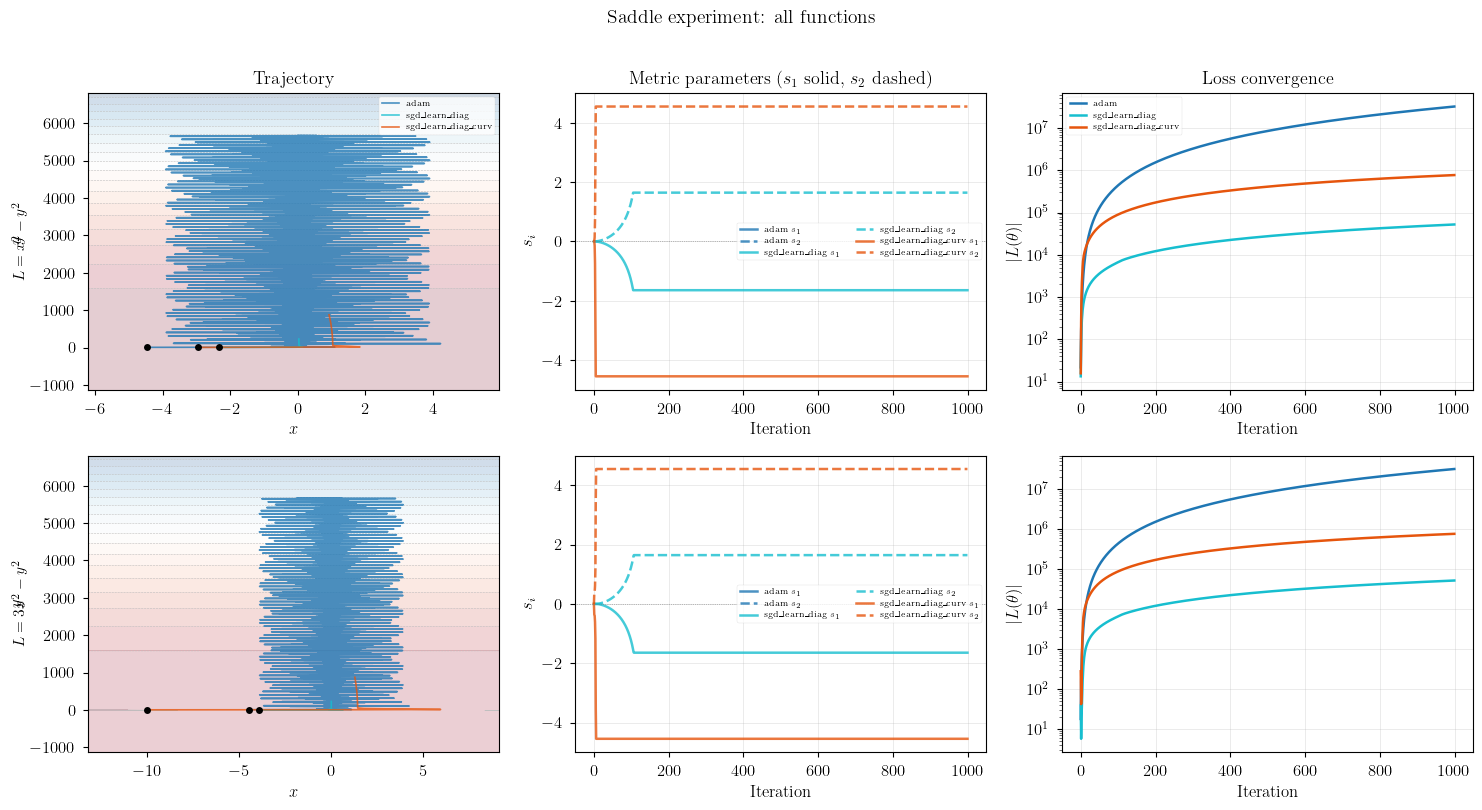

In [8]:
available_funcs = [f for f in FUNCTIONS if f in all_history_data]
n_funcs = len(available_funcs)

if n_funcs == 0:
    print("No data available for grid plot.")
else:
    fig, axes = plt.subplots(n_funcs, 3, figsize=(15, 4 * n_funcs))
    if n_funcs == 1:
        axes = axes[np.newaxis, :]

    for row, func_name in enumerate(available_funcs):
        history_data = all_history_data[func_name]
        title = FUNCTION_TITLES.get(func_name, func_name)
        opts = [k for k in history_data if k in OPTIMIZERS]

        # Auto-scale to trajectory extent
        xlim, ylim = _auto_lims(history_data)

        # Column 0: Trajectories overlaid
        ax = axes[row, 0]
        X, Y, Z = _loss_grid(func_name, xlim, ylim)
        ax.contour(X, Y, Z, levels=20, colors="0.75", linewidths=0.4)
        ax.contourf(X, Y, Z, levels=20, cmap="RdBu_r", alpha=0.2)
        for opt_name in opts:
            data = history_data.get(opt_name, {})
            px = data.get(KEY_PARAM_X)
            py = data.get(KEY_PARAM_Y)
            if px is not None and py is not None:
                ax.plot(px, py, color=colors.get(opt_name, "#333"),
                        linewidth=1.2, alpha=0.8,
                        label=opt_name.replace("_", r"\_"))
                ax.plot(px[0], py[0], "ko", markersize=5, zorder=4)
        ax.set_xlabel(r"$x$")
        ax.set_ylabel(r"$y$")
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        if row == 0:
            ax.set_title("Trajectory")
            ax.legend(fontsize=6, loc="upper right")
        ax.text(-0.15, 0.5, title, transform=ax.transAxes, fontsize=11,
                va="center", ha="right", rotation=90)

        # Column 1: s_i evolution (overlaid, diag and curv only)
        ax = axes[row, 1]
        has_s = False
        for opt_name in opts:
            data = history_data.get(opt_name, {})
            s0 = data.get(KEY_S0)
            s1 = data.get(KEY_S1)
            if s0 is not None and s1 is not None:
                has_s = True
                c = colors.get(opt_name, "#333")
                steps = np.arange(len(s0))
                lbl = opt_name.replace("_", r"\_")
                ax.plot(steps, s0, color=c, linestyle="-", alpha=0.8,
                        label=f"{lbl} $s_1$")
                ax.plot(steps, s1, color=c, linestyle="--", alpha=0.8,
                        label=f"{lbl} $s_2$")
        ax.axhline(0, color="0.5", linewidth=0.5, linestyle=":")
        ax.set_xlabel("Iteration")
        ax.set_ylabel(r"$s_i$")
        if row == 0:
            ax.set_title(r"Metric parameters ($s_1$ solid, $s_2$ dashed)")
        if has_s:
            ax.legend(fontsize=6, ncol=2)
        ax.grid(True)

        # Column 2: Loss curves (all optimizers)
        ax = axes[row, 2]
        for opt_name in opts:
            data = history_data.get(opt_name, {})
            loss = data.get("function_value")
            if loss is not None:
                steps = np.arange(len(loss))
                ax.plot(steps, np.abs(loss), color=colors.get(opt_name, "#333"),
                        label=opt_name.replace("_", r"\_"))
        ax.set_xlabel("Iteration")
        ax.set_ylabel(r"$|L(\theta)|$")
        ax.set_yscale("log")
        if row == 0:
            ax.set_title("Loss convergence")
            ax.legend(fontsize=6)
        ax.grid(True)

    fig.suptitle("Saddle experiment: all functions", fontsize=14, y=1.01)
    fig.tight_layout()
    plt.show()

# Plot 6: Metric Anisotropy

Core claim: the curvature correction drives metric anisotropy ($|s_1 - s_2|$)
while the base learnable rule keeps $s_1 \approx s_2$ (symmetric gradients).

On the canonical saddle with mean-centering, $s_1 = -s_2$, so $|s_1 - s_2| = 2|s_1|$.

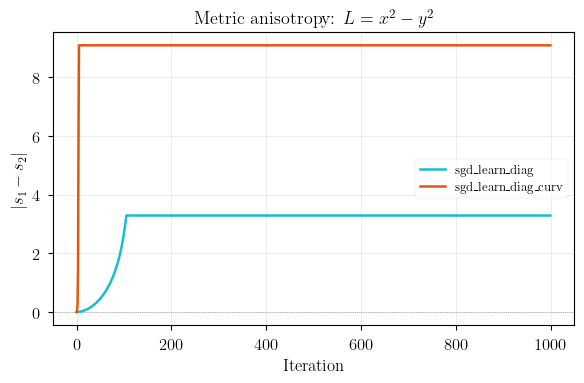

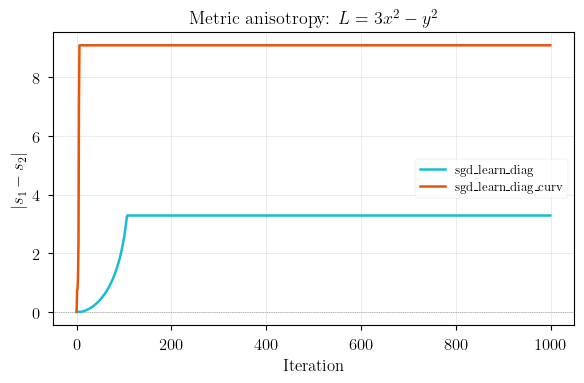

In [9]:
def plot_metric_anisotropy(func_name, history_data,
                           learnable_opts=("sgd_learn_diag", "sgd_learn_diag_curv")):
    """Plot |s_1 - s_2| for learnable optimizers."""
    title = FUNCTION_TITLES.get(func_name, func_name)
    fig, ax = plt.subplots(figsize=FIGSIZE)

    has_data = False
    for opt_name in learnable_opts:
        data = history_data.get(opt_name, {})
        s0 = data.get(KEY_S0)
        s1 = data.get(KEY_S1)
        if s0 is not None and s1 is not None:
            has_data = True
            aniso = np.abs(s0 - s1)
            steps = np.arange(len(aniso))
            ax.plot(steps, aniso, color=colors.get(opt_name, "#333"),
                    label=opt_name.replace("_", r"\_"))

    if not has_data:
        plt.close(fig)
        print(f"  [skip] No s_i data for anisotropy plot ({func_name})")
        return None

    ax.axhline(0, color="0.5", linewidth=0.5, linestyle=":")
    ax.set_xlabel("Iteration")
    ax.set_ylabel(r"$|s_1 - s_2|$")
    ax.set_title(f"Metric anisotropy: {title}")
    ax.legend(fontsize=9)
    ax.grid(True)
    fig.tight_layout()
    return fig


for func_name in FUNCTIONS:
    if func_name not in all_history_data:
        continue
    fig = plot_metric_anisotropy(func_name, all_history_data[func_name])
    if fig is not None:
        plt.show()

# Clip Comparison: With clip (iter 0) vs No clip (iter 1)

Side-by-side comparison of all diagnostics. The clip is structurally necessary:
`exp(s) * g^2` drives s exponentially while regularization is only linear,
so s diverges without a hard bound. The question is what clip value to use.

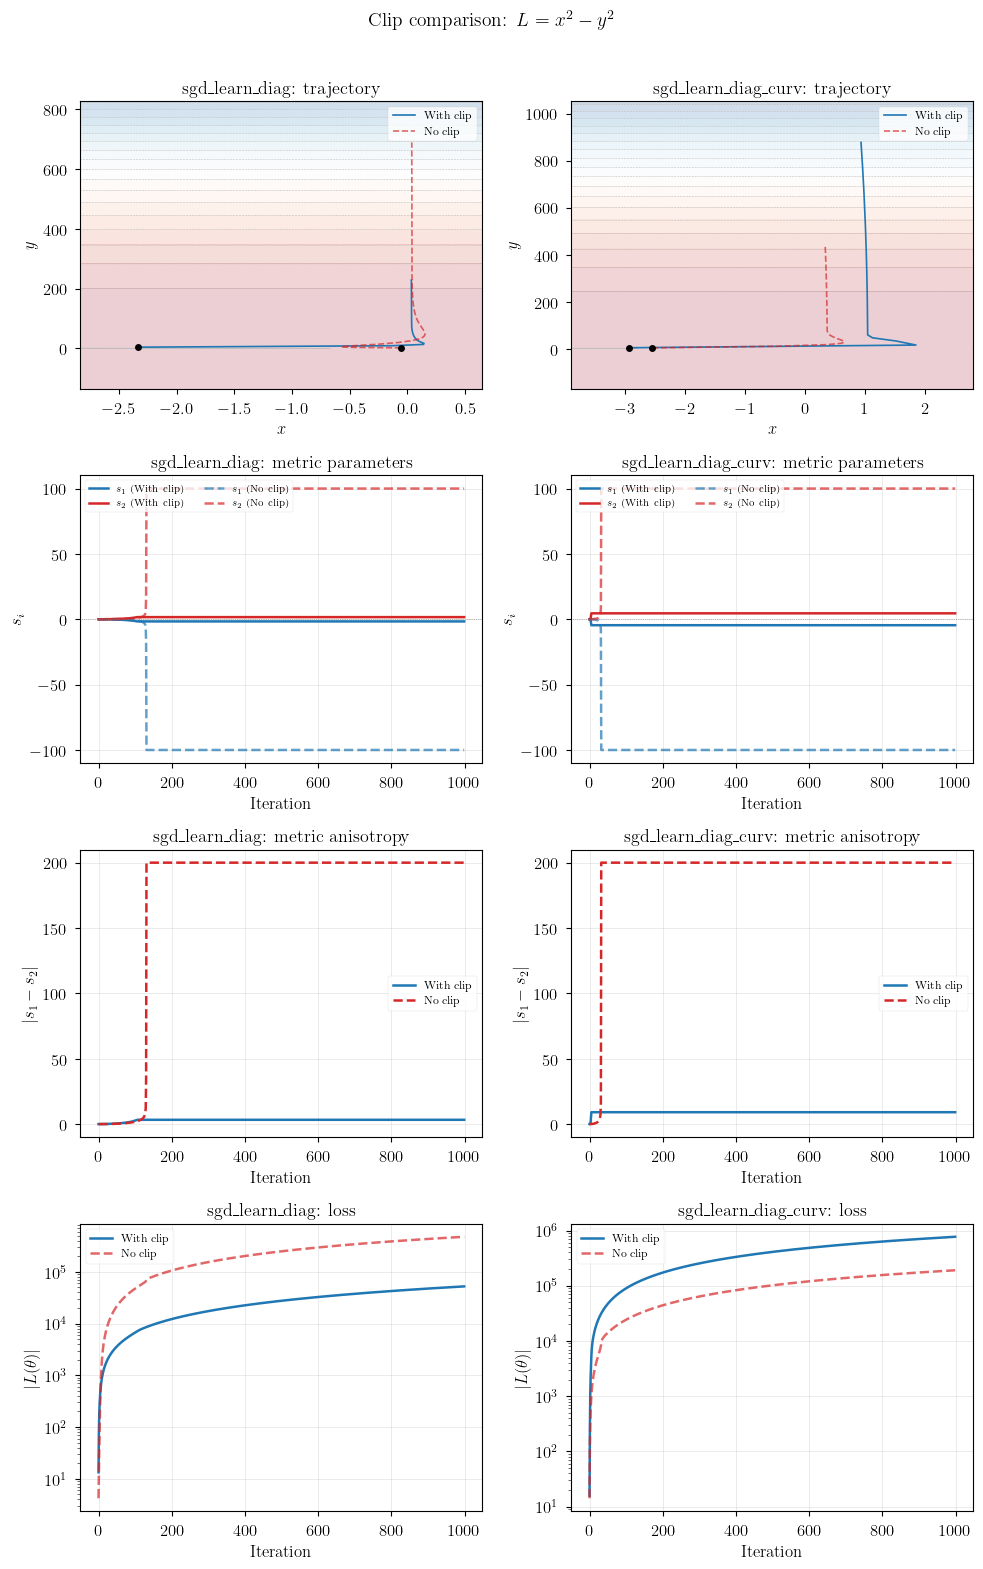


  CLIP COMPARISON SUMMARY

  sgd_learn_diag:
    With clip (default):
      s_1 final=-1.64, s_2 final=1.64, |s1-s2|=3.29
      Loss final=-52205.00
      Status: SATURATED at |s|=1.6
    No clip:
      s_1 final=-100.00, s_2 final=100.00, |s1-s2|=200.00
      Loss final=-474411.00
      Status: SATURATED at |s|=100.0

  sgd_learn_diag_curv:
    With clip (default):
      s_1 final=-4.55, s_2 final=4.55, |s1-s2|=9.10
      Loss final=-769689.00
      Status: SATURATED at |s|=4.5
    No clip:
      s_1 final=-100.00, s_2 final=100.00, |s1-s2|=200.00
      Loss final=-190605.00
      Status: SATURATED at |s|=100.0


In [10]:
def plot_clip_comparison(func_name, learnable_opts=("sgd_learn_diag", "sgd_learn_diag_curv")):
    """Full comparison: clipped (itr 0) vs unclipped (itr 1).

    4 rows: trajectory, s_i evolution, anisotropy, loss
    2 columns: one per learnable optimizer
    Each panel overlays both iterations.
    """
    d0 = all_data.get(0, {}).get(func_name)
    d1 = all_data.get(1, {}).get(func_name)
    if d0 is None or d1 is None:
        print(f"  [skip] Need both iterations for clip comparison ({func_name})")
        return None

    title = FUNCTION_TITLES.get(func_name, func_name)
    n_opts = len(learnable_opts)
    fig, axes = plt.subplots(4, n_opts, figsize=(5 * n_opts, 16), squeeze=False)

    itr_styles = {0: ("-", 1.0, "With clip"), 1: ("--", 0.7, "No clip")}

    for col, opt_name in enumerate(learnable_opts):
        opt_label = opt_name.replace("_", r"\_")

        # Row 0: Trajectory
        ax = axes[0, col]
        xlim, ylim = _auto_lims({
            **{f"{k}_0": v for k, v in d0.items()},
            **{f"{k}_1": v for k, v in d1.items()},
        })
        # Recompute auto lims from both iterations for this optimizer
        all_px, all_py = [], []
        for itr in [0, 1]:
            d = all_data[itr].get(func_name, {}).get(opt_name, {})
            px, py = d.get(KEY_PARAM_X), d.get(KEY_PARAM_Y)
            if px is not None:
                all_px.extend(px.tolist())
                all_py.extend(py.tolist())
        if all_px:
            pad = 0.2
            xmn, xmx = min(all_px), max(all_px)
            ymn, ymx = min(all_py), max(all_py)
            dx = max(xmx - xmn, 0.5) * pad
            dy = max(ymx - ymn, 0.5) * pad
            xlim, ylim = (xmn - dx, xmx + dx), (ymn - dy, ymx + dy)
        X, Y, Z = _loss_grid(func_name, xlim, ylim, n=100)
        ax.contour(X, Y, Z, levels=20, colors="0.75", linewidths=0.4)
        ax.contourf(X, Y, Z, levels=20, cmap="RdBu_r", alpha=0.2)
        for itr, (ls, alpha, lbl) in itr_styles.items():
            d = all_data[itr].get(func_name, {}).get(opt_name, {})
            px, py = d.get(KEY_PARAM_X), d.get(KEY_PARAM_Y)
            if px is not None:
                c = "#1f77b4" if itr == 0 else "#d62728"
                ax.plot(px, py, color=c, linestyle=ls, linewidth=1.2, alpha=alpha, label=lbl)
                ax.plot(px[0], py[0], "ko", markersize=5, zorder=4)
        ax.set_xlabel(r"$x$")
        ax.set_ylabel(r"$y$")
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_title(f"{opt_label}: trajectory")
        ax.legend(fontsize=8)

        # Row 1: s_i evolution
        ax = axes[1, col]
        for itr, (ls, alpha, lbl) in itr_styles.items():
            d = all_data[itr].get(func_name, {}).get(opt_name, {})
            s0, s1 = d.get(KEY_S0), d.get(KEY_S1)
            if s0 is not None:
                steps = np.arange(len(s0))
                ax.plot(steps, s0, color="#1f77b4", linestyle=ls, alpha=alpha,
                        label=f"$s_1$ ({lbl})")
                ax.plot(steps, s1, color="#d62728", linestyle=ls, alpha=alpha,
                        label=f"$s_2$ ({lbl})")
        ax.axhline(0, color="0.5", linewidth=0.5, linestyle=":")
        ax.set_xlabel("Iteration")
        ax.set_ylabel(r"$s_i$")
        ax.set_title(f"{opt_label}: metric parameters")
        ax.legend(fontsize=7, ncol=2)
        ax.grid(True)

        # Row 2: Anisotropy |s_1 - s_2|
        ax = axes[2, col]
        for itr, (ls, alpha, lbl) in itr_styles.items():
            d = all_data[itr].get(func_name, {}).get(opt_name, {})
            s0, s1 = d.get(KEY_S0), d.get(KEY_S1)
            if s0 is not None:
                aniso = np.abs(s0 - s1)
                steps = np.arange(len(aniso))
                c = "#1f77b4" if itr == 0 else "#d62728"
                ax.plot(steps, aniso, color=c, linestyle=ls, label=lbl)
        ax.set_xlabel("Iteration")
        ax.set_ylabel(r"$|s_1 - s_2|$")
        ax.set_title(f"{opt_label}: metric anisotropy")
        ax.legend(fontsize=8)
        ax.grid(True)

        # Row 3: Loss
        ax = axes[3, col]
        for itr, (ls, alpha, lbl) in itr_styles.items():
            d = all_data[itr].get(func_name, {}).get(opt_name, {})
            loss = d.get("function_value")
            if loss is not None:
                steps = np.arange(len(loss))
                c = "#1f77b4" if itr == 0 else "#d62728"
                ax.plot(steps, np.abs(loss), color=c, linestyle=ls, alpha=alpha, label=lbl)
        ax.set_xlabel("Iteration")
        ax.set_ylabel(r"$|L(\theta)|$")
        ax.set_yscale("log")
        ax.set_title(f"{opt_label}: loss")
        ax.legend(fontsize=8)
        ax.grid(True)

    fig.suptitle(f"Clip comparison: {title}", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    return fig


for func_name in FUNCTIONS:
    if func_name in all_data.get(0, {}) and func_name in all_data.get(1, {}):
        fig = plot_clip_comparison(func_name)
        if fig is not None:
            plt.show()

# Print numerical summary
print("\n" + "="*70)
print("  CLIP COMPARISON SUMMARY")
print("="*70)
for opt in ["sgd_learn_diag", "sgd_learn_diag_curv"]:
    print(f"\n  {opt}:")
    for itr, lbl in ITERATIONS.items():
        d = all_data.get(itr, {}).get("saddle", {}).get(opt, {})
        s0, s1 = d.get(KEY_S0), d.get(KEY_S1)
        loss = d.get("function_value")
        if s0 is not None:
            print(f"    {lbl}:")
            print(f"      s_1 final={s0[-1]:.2f}, s_2 final={s1[-1]:.2f}, |s1-s2|={abs(s0[-1]-s1[-1]):.2f}")
            print(f"      Loss final={loss[-1]:.2f}")
            # Check if saturated
            clip_val = max(abs(s0[-1]), abs(s1[-1]))
            s_range = abs(s0[-1] - s1[-1])
            if len(s0) > 100 and abs(s0[-1] - s0[-100]) < 0.01:
                print(f"      Status: SATURATED at |s|={clip_val:.1f}")
            else:
                print(f"      Status: Still evolving, max |s|={clip_val:.1f}")

# Rosenbrock Comparison: Does $s_i$ stabilize near a minimum?

On the saddle, $s_i$ diverges without clip because $g \neq 0$ everywhere.
On Rosenbrock, $g \to 0$ near the minimum — does this naturally stabilize $s$?
If so, the clip is a safety net for saddle-like transients, not a fundamental limitation.

Finding best run for adam...


  adam: run_34
Finding best run for sgd_learn_diag...


  sgd_learn_diag: run_22
Finding best run for sgd_learn_diag_curv...


  sgd_learn_diag_curv: run_38
Processing adam...
Processing sgd_learn_diag...
Processing sgd_learn_diag_curv...


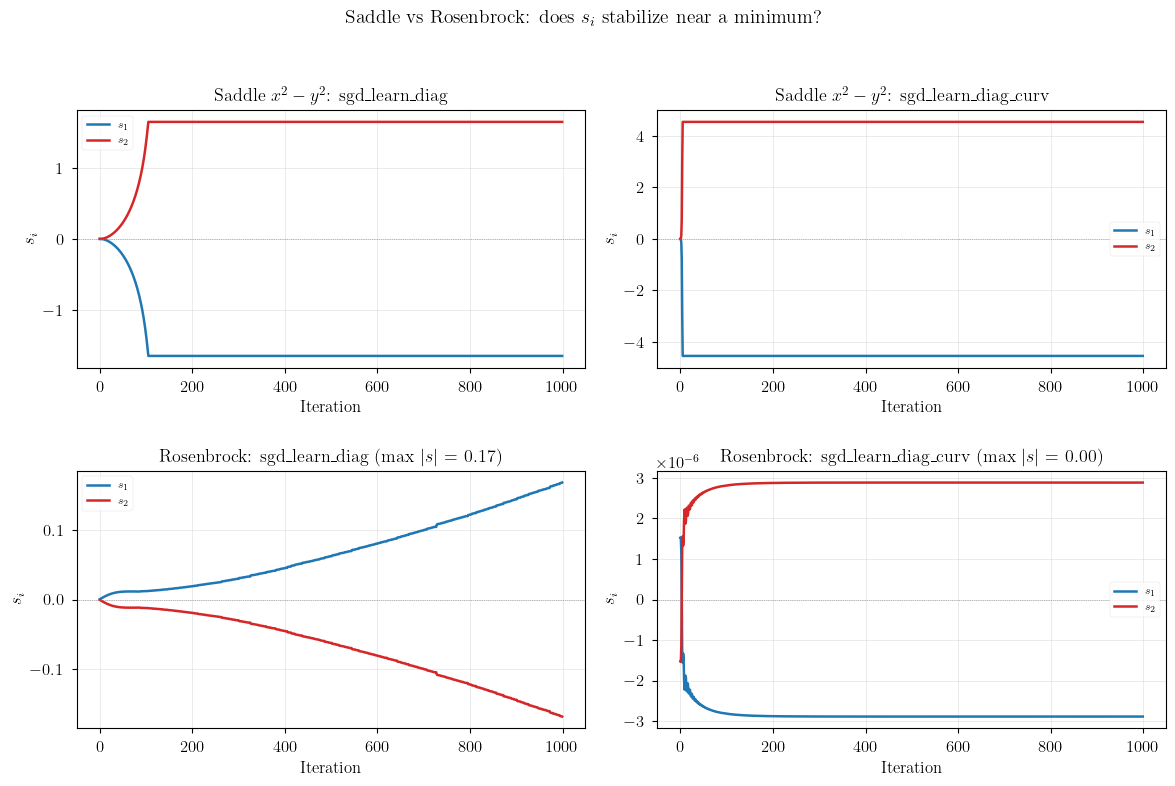

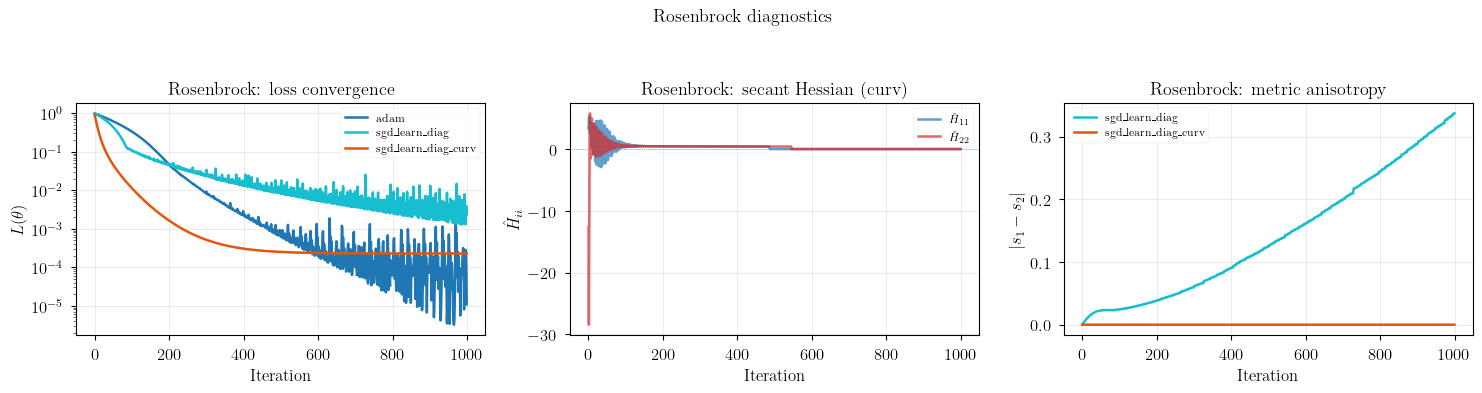


  ROSENBROCK s_i SUMMARY

  sgd_learn_diag:
    s_1 final=0.1685, s_2 final=-0.1685
    max |s| = 0.17
    |s1-s2| final = 0.3371
    Loss final = 0.002411
    Saturated at clip? NO

  sgd_learn_diag_curv:
    s_1 final=-0.0000, s_2 final=0.0000
    max |s| = 0.00
    |s1-s2| final = 0.0000
    Loss final = 0.000227
    Saturated at clip? NO


In [11]:
# Load Rosenbrock diagnostics (itr 4 = with diagnostics)
ROSEN_OPTS = ["adam", "sgd_learn_diag", "sgd_learn_diag_curv"]
rosen_best = load_best_runs(
    backend=BACKEND, optimizers=ROSEN_OPTS,
    task_tag="small_examples_rosenbrock",
    project=PROJECT, entity=ENTITY, results_dir=RESULTS_DIR,
    metric_key="sweep_metric", direction="minimize",
    sort_metric="sweep_metric", sort_order="+", iteration=4,
)
rosen_hist = extract_history(BACKEND, rosen_best, HISTORY_KEYS)

# Side-by-side: saddle vs Rosenbrock s_i evolution
learnable = ["sgd_learn_diag", "sgd_learn_diag_curv"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for col, opt_name in enumerate(learnable):
    opt_label = opt_name.replace("_", r"\_")

    # Top row: saddle s_i
    ax = axes[0, col]
    sd = all_data.get(0, {}).get("saddle", {}).get(opt_name, {})
    s0, s1 = sd.get(KEY_S0), sd.get(KEY_S1)
    if s0 is not None:
        steps = np.arange(len(s0))
        ax.plot(steps, s0, color="#1f77b4", label=r"$s_1$")
        ax.plot(steps, s1, color="#d62728", label=r"$s_2$")
    ax.axhline(0, color="0.5", linewidth=0.5, linestyle=":")
    ax.set_xlabel("Iteration")
    ax.set_ylabel(r"$s_i$")
    ax.set_title(f"Saddle $x^2 - y^2$: {opt_label}")
    ax.legend(fontsize=8)
    ax.grid(True)

    # Bottom row: Rosenbrock s_i
    ax = axes[1, col]
    rd = rosen_hist.get(opt_name, {})
    s0, s1 = rd.get(KEY_S0), rd.get(KEY_S1)
    if s0 is not None:
        steps = np.arange(len(s0))
        ax.plot(steps, s0, color="#1f77b4", label=r"$s_1$")
        ax.plot(steps, s1, color="#d62728", label=r"$s_2$")
        # Check if clipped
        s_max = max(np.max(np.abs(s0)), np.max(np.abs(s1)))
        ax.set_title(f"Rosenbrock: {opt_label} (max $|s|$ = {s_max:.2f})")
    else:
        ax.set_title(f"Rosenbrock: {opt_label} (no data)")
    ax.axhline(0, color="0.5", linewidth=0.5, linestyle=":")
    ax.set_xlabel("Iteration")
    ax.set_ylabel(r"$s_i$")
    ax.legend(fontsize=8)
    ax.grid(True)

fig.suptitle(r"Saddle vs Rosenbrock: does $s_i$ stabilize near a minimum?", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Also show Rosenbrock loss convergence and H_hat
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
ax = axes[0]
for opt_name in ROSEN_OPTS:
    rd = rosen_hist.get(opt_name, {})
    loss = rd.get("function_value")
    if loss is not None:
        steps = np.arange(len(loss))
        ax.plot(steps, loss, color=colors.get(opt_name, "#333"),
                label=opt_name.replace("_", r"\_"))
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$L(\theta)$")
ax.set_yscale("log")
ax.set_title("Rosenbrock: loss convergence")
ax.legend(fontsize=8)
ax.grid(True)

# H_hat for curv
ax = axes[1]
rd = rosen_hist.get("sgd_learn_diag_curv", {})
h0, h1 = rd.get(KEY_H0), rd.get(KEY_H1)
if h0 is not None:
    steps = np.arange(len(h0))
    ax.plot(steps, h0, color="#1f77b4", alpha=0.7, label=r"$\hat{H}_{11}$")
    ax.plot(steps, h1, color="#d62728", alpha=0.7, label=r"$\hat{H}_{22}$")
    ax.axhline(0, color="0.5", linewidth=0.5, linestyle=":")
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$\hat{H}_{ii}$")
ax.set_title("Rosenbrock: secant Hessian (curv)")
ax.legend(fontsize=8)
ax.grid(True)

# Anisotropy comparison
ax = axes[2]
for opt_name in learnable:
    rd = rosen_hist.get(opt_name, {})
    s0, s1 = rd.get(KEY_S0), rd.get(KEY_S1)
    if s0 is not None:
        aniso = np.abs(s0 - s1)
        steps = np.arange(len(aniso))
        ax.plot(steps, aniso, color=colors.get(opt_name, "#333"),
                label=opt_name.replace("_", r"\_"))
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$|s_1 - s_2|$")
ax.set_title("Rosenbrock: metric anisotropy")
ax.legend(fontsize=8)
ax.grid(True)

fig.suptitle("Rosenbrock diagnostics", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# Print summary
print("\n" + "="*60)
print("  ROSENBROCK s_i SUMMARY")
print("="*60)
for opt_name in learnable:
    rd = rosen_hist.get(opt_name, {})
    s0, s1 = rd.get(KEY_S0), rd.get(KEY_S1)
    loss = rd.get("function_value")
    if s0 is not None:
        s_max = max(np.max(np.abs(s0)), np.max(np.abs(s1)))
        saturated = len(s0) > 100 and abs(s0[-1] - s0[-100]) < 0.01 and s_max > 3.0
        print(f"\n  {opt_name}:")
        print(f"    s_1 final={s0[-1]:.4f}, s_2 final={s1[-1]:.4f}")
        print(f"    max |s| = {s_max:.2f}")
        print(f"    |s1-s2| final = {abs(s0[-1]-s1[-1]):.4f}")
        print(f"    Loss final = {loss[-1]:.6f}")
        print(f"    Saturated at clip? {'YES' if saturated else 'NO'}")

# Standard Diagnostics

Reuse the shared diagnostic plotting infrastructure from `analysis_utils`.
Requires `--diagnostics` flag during sweep runs.

Processing adam...
Processing sgd_learn_diag...
Processing sgd_learn_diag_curv...


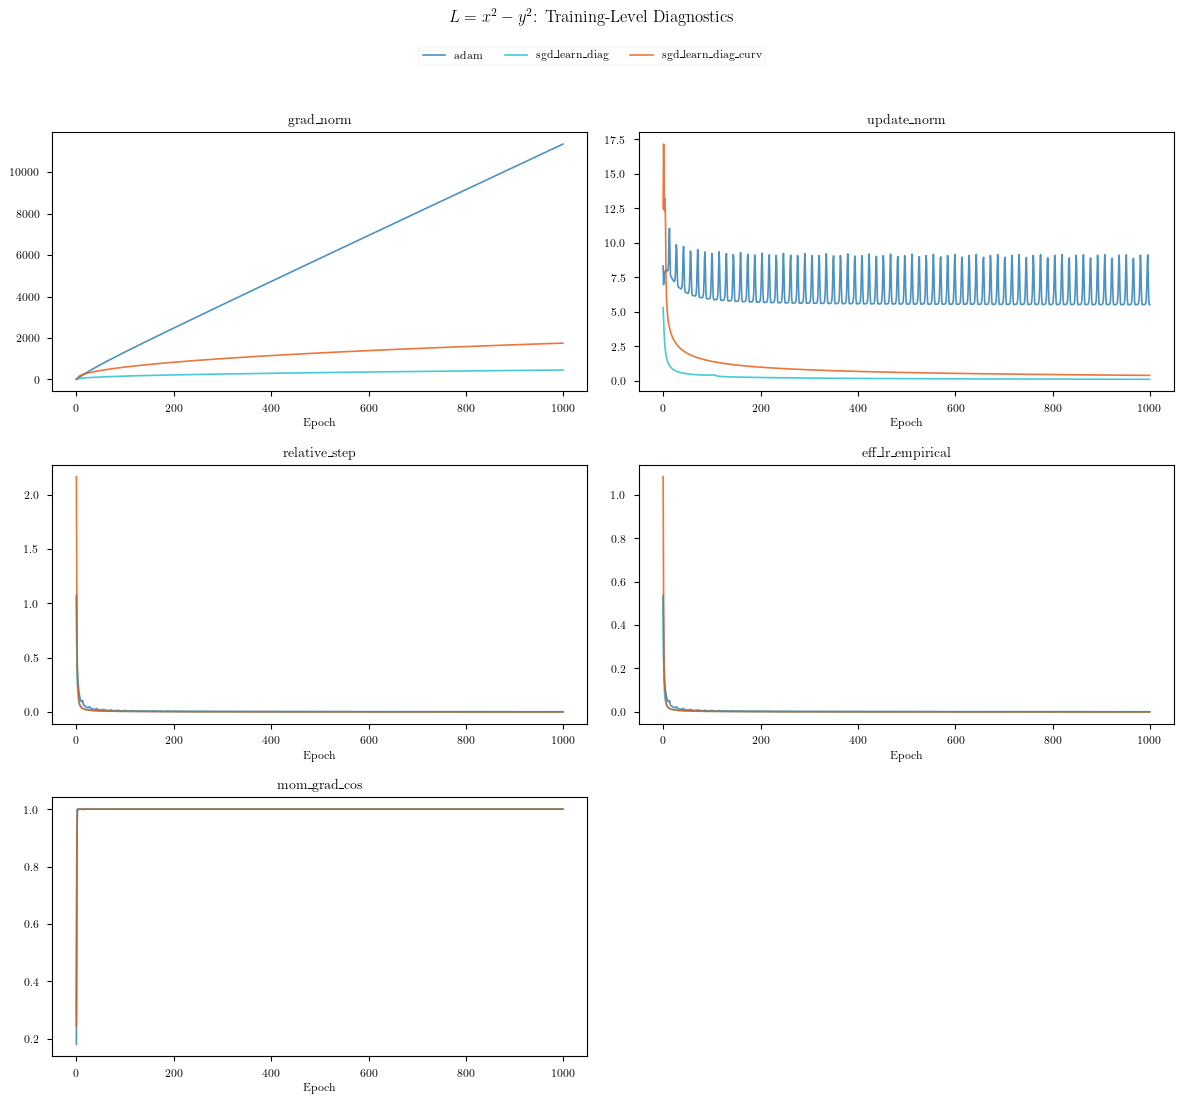

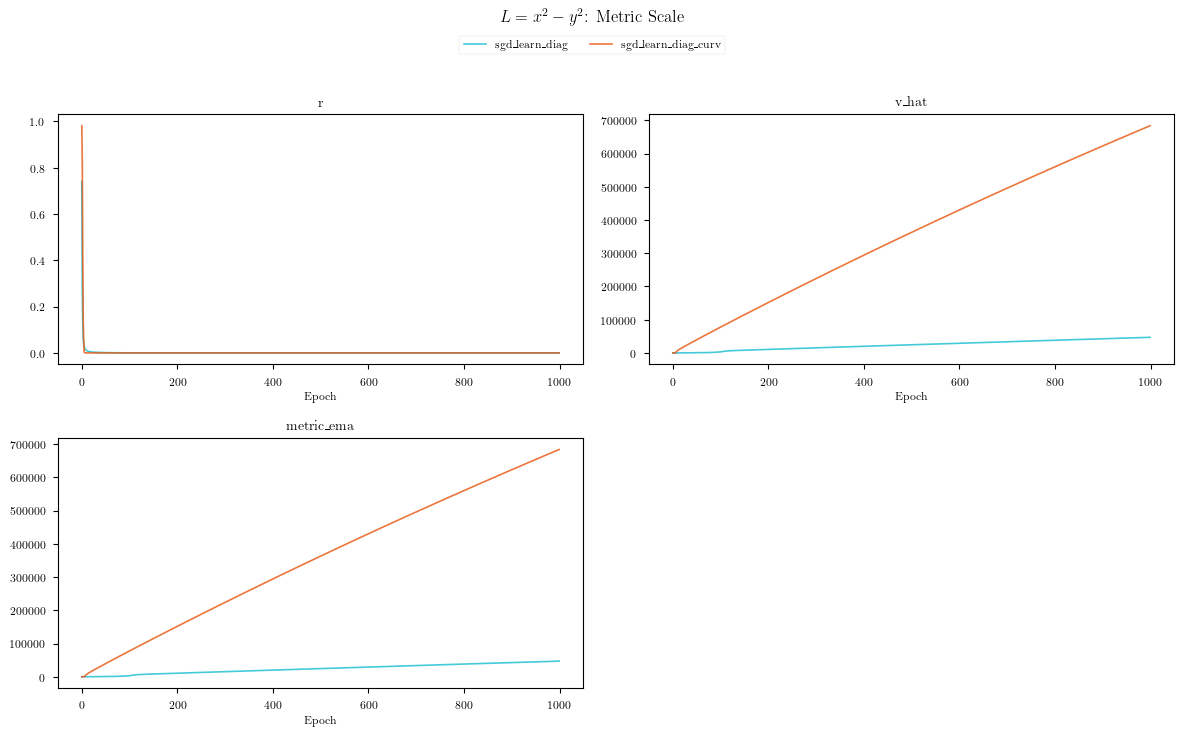

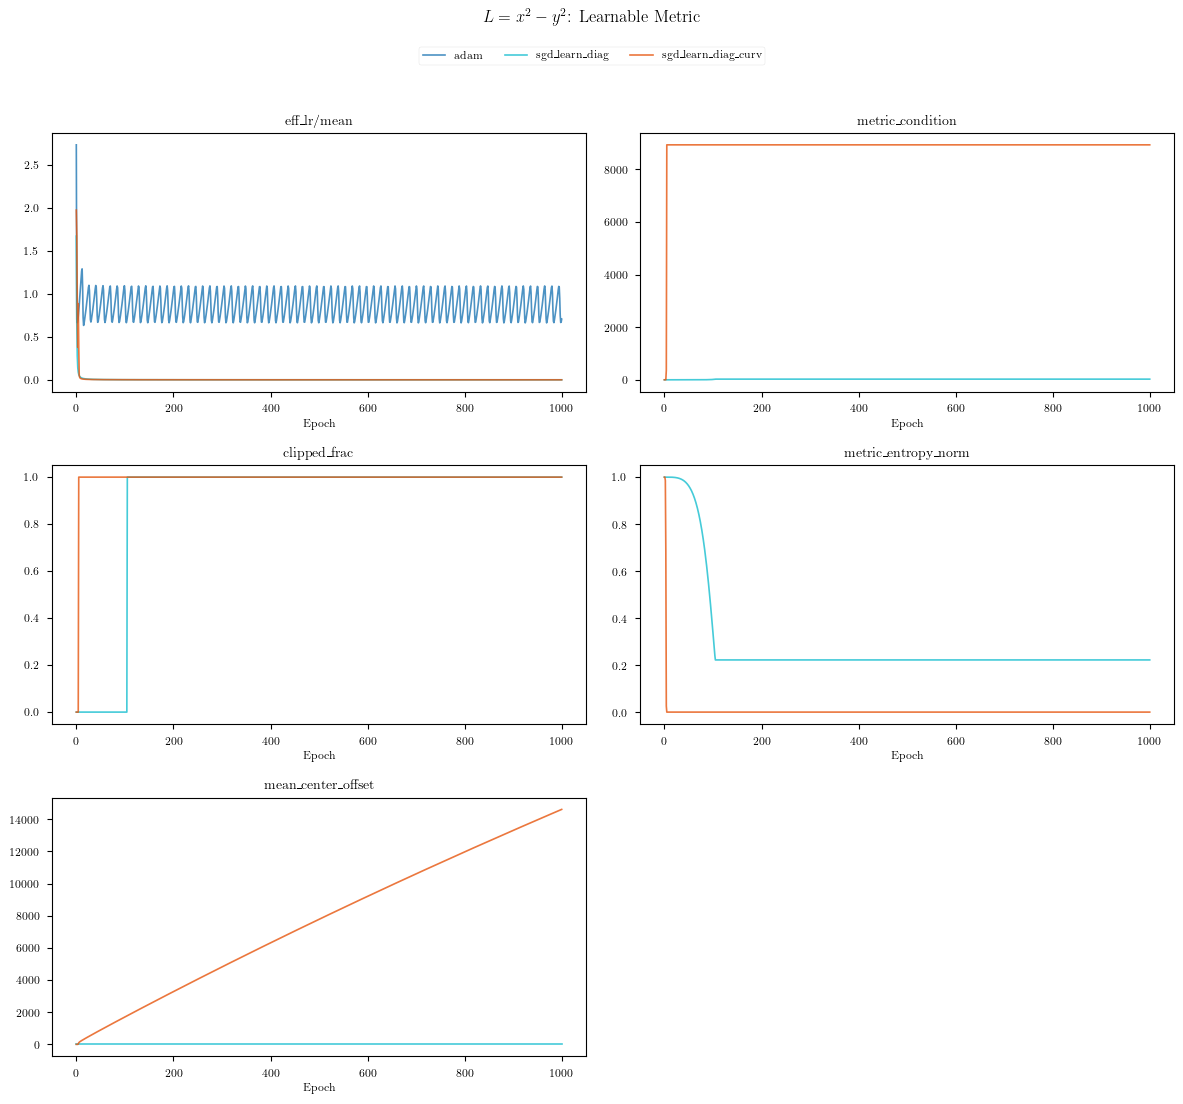

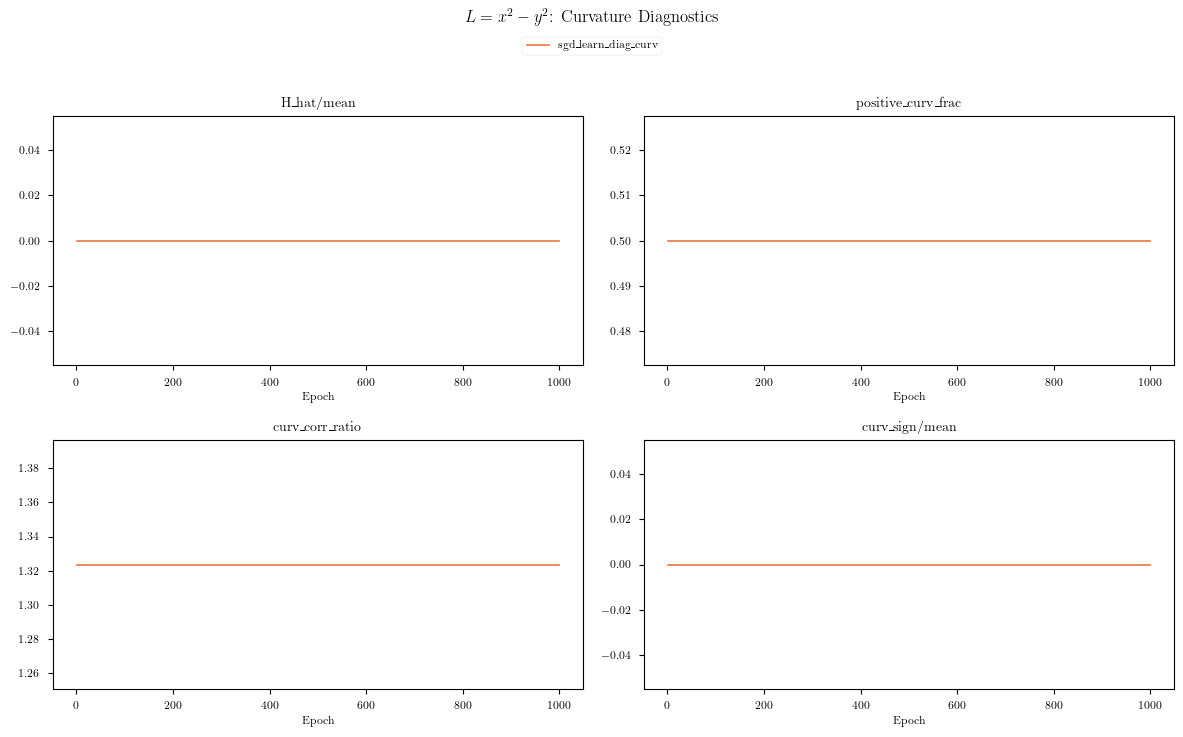

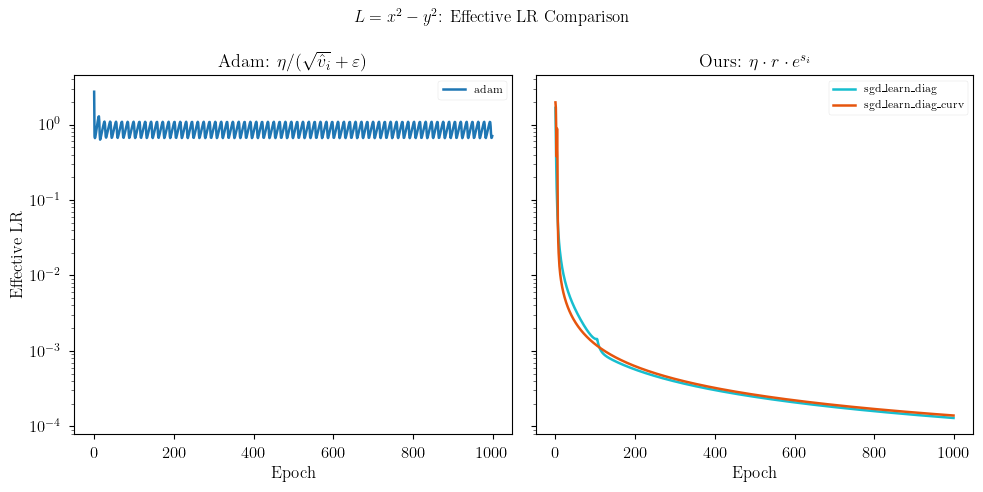

Processing adam...
Processing sgd_learn_diag...
Processing sgd_learn_diag_curv...


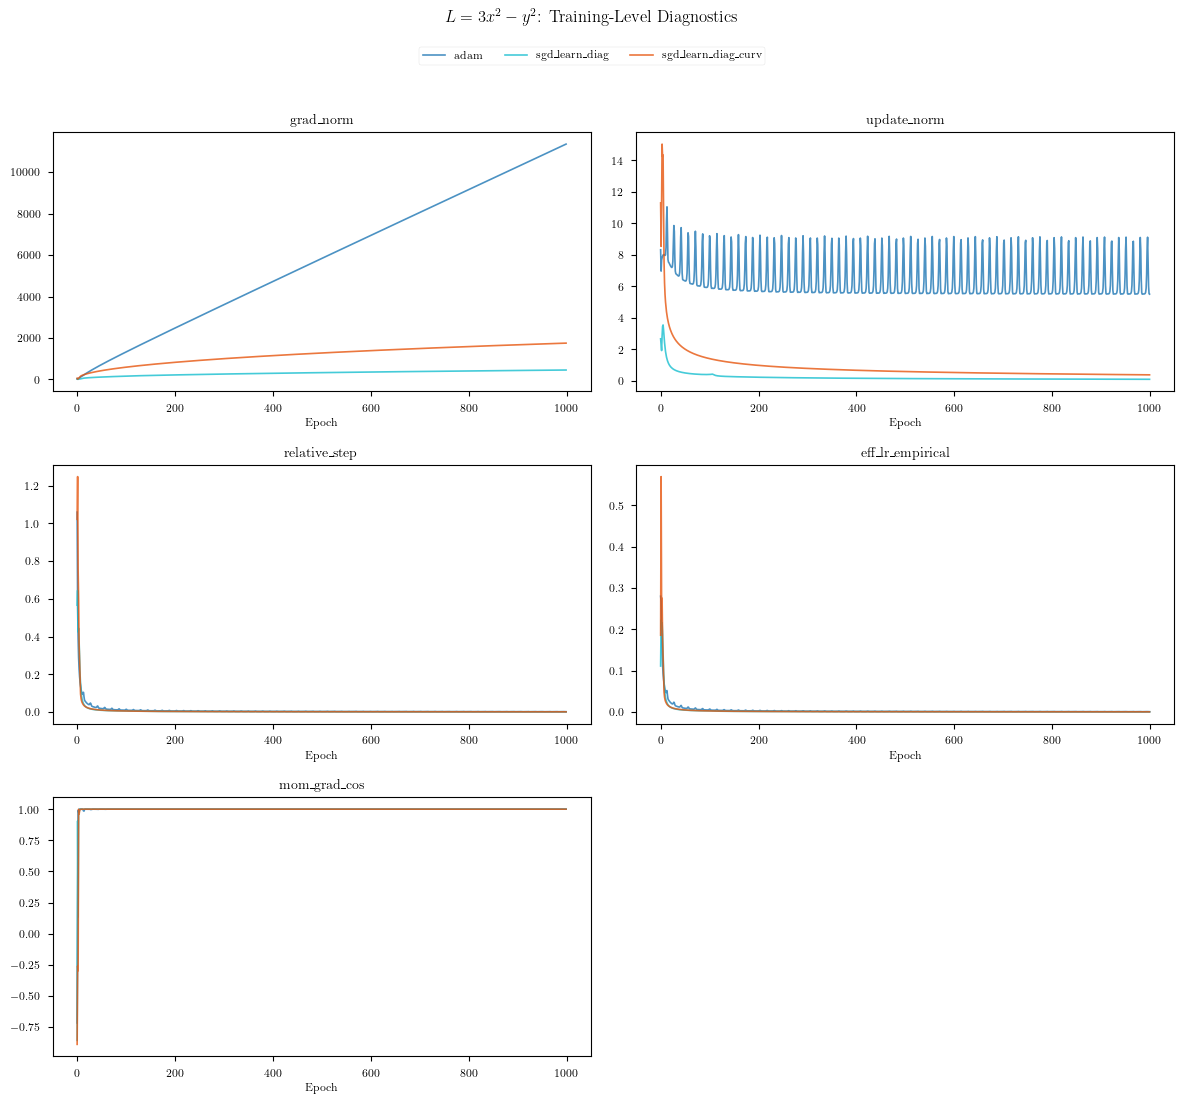

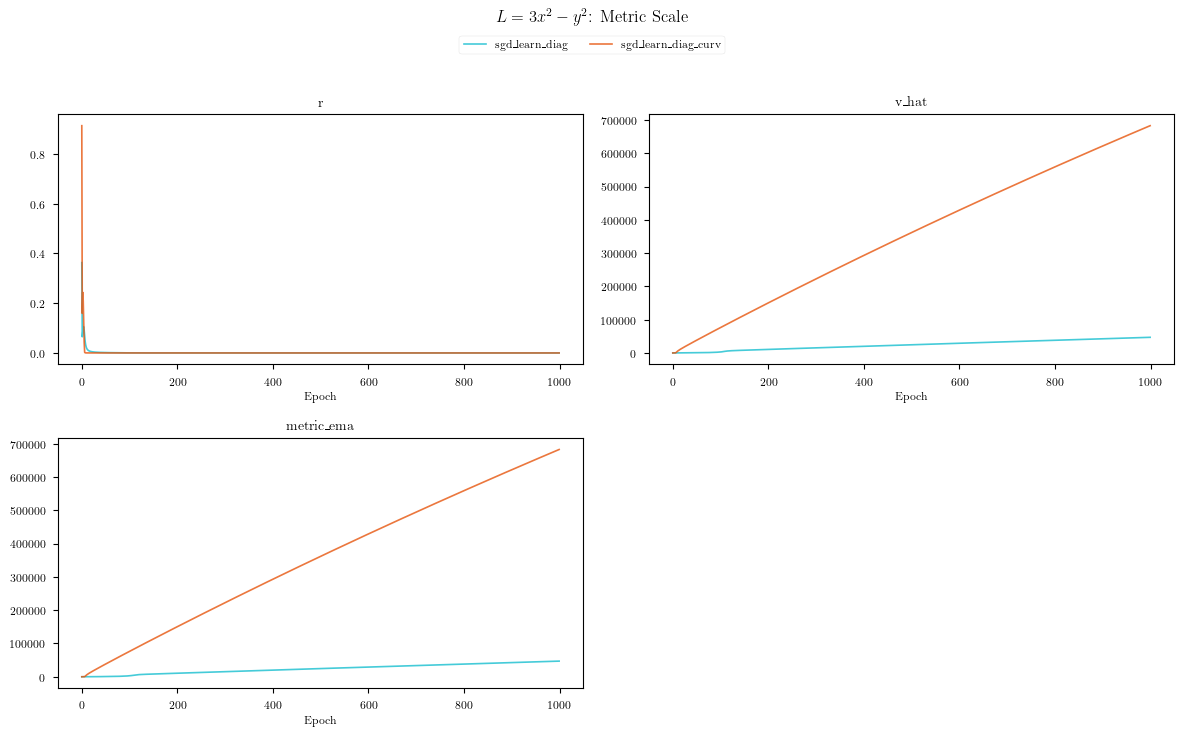

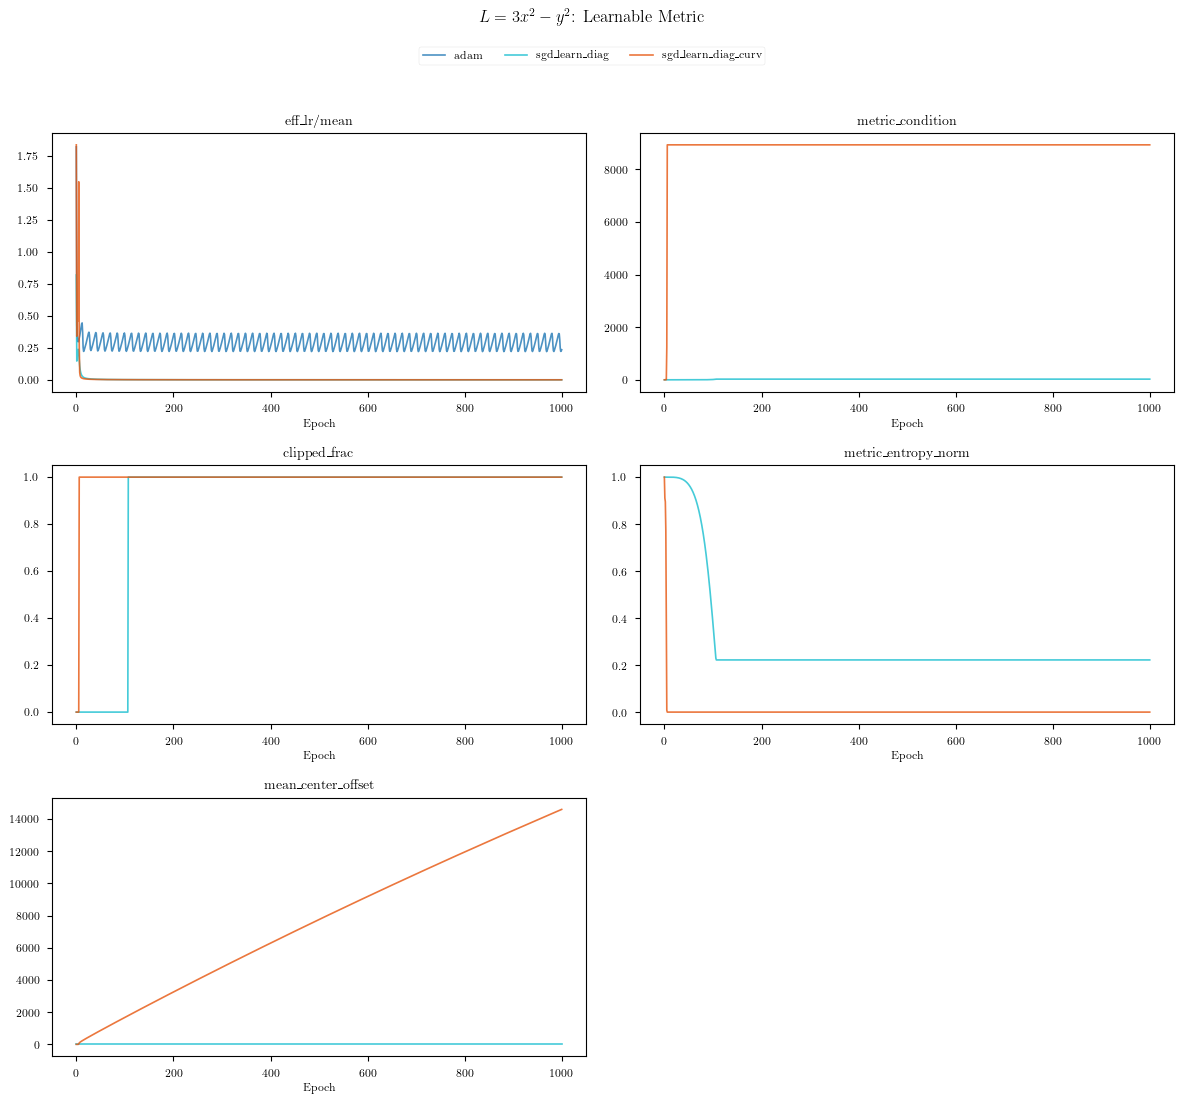

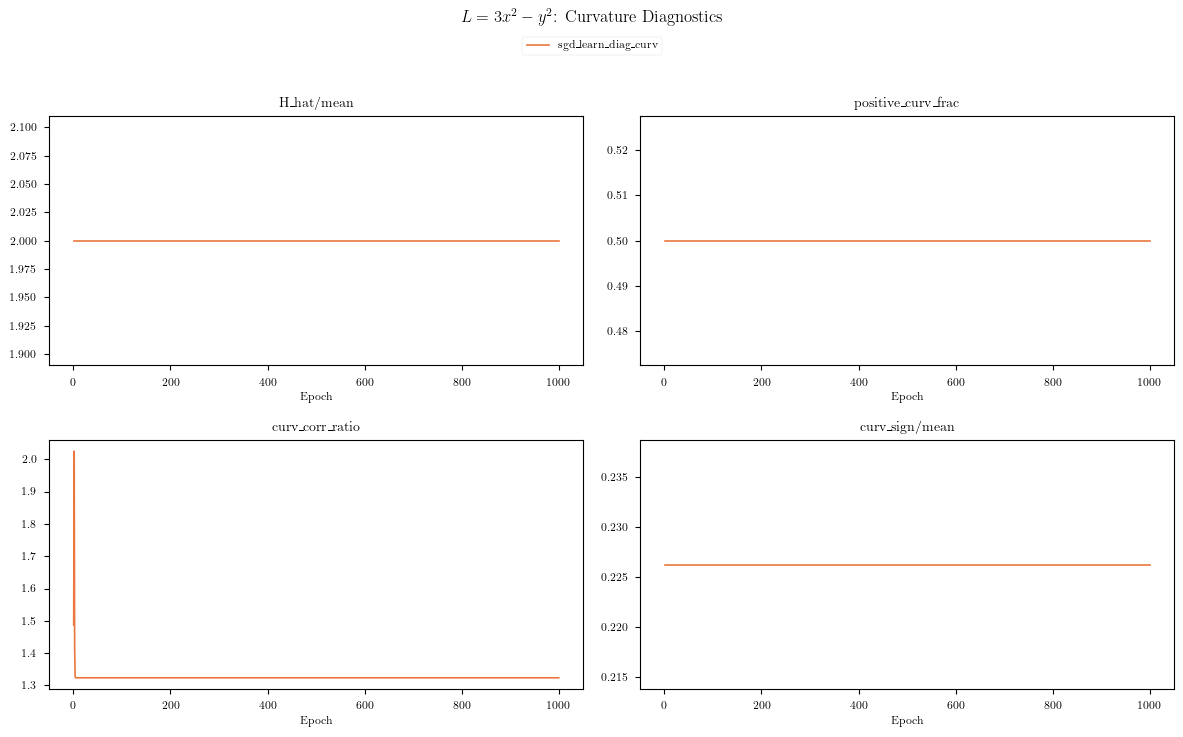

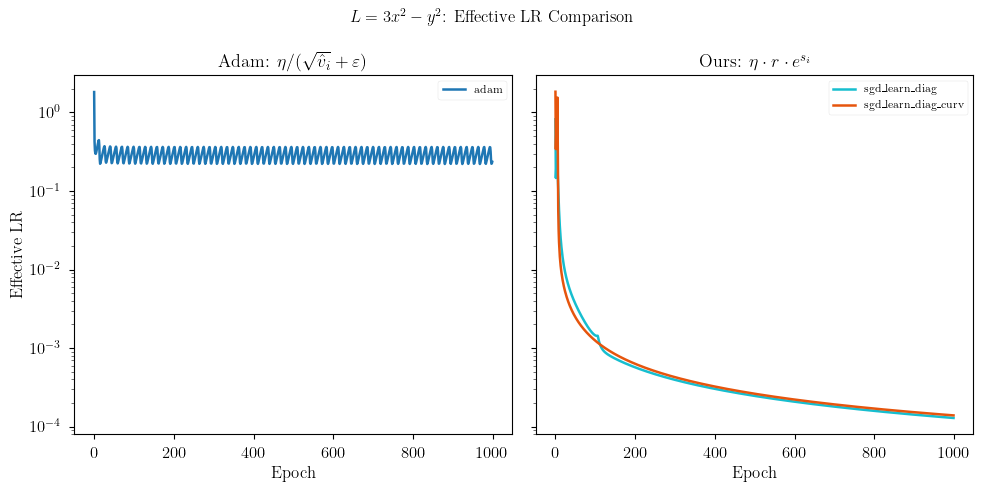

In [12]:
diag_keys = (
    DIAG_KEYS_METRIC_SCALE + DIAG_KEYS_LEARNABLE +
    DIAG_KEYS_CURVATURE + DIAG_KEYS_TRAINING
)

for func_name in available_funcs:
    best_runs = all_best_runs.get(func_name, {})
    if not best_runs:
        continue
    diag_data = extract_history(BACKEND, best_runs, diag_keys)
    title_fn = FUNCTION_TITLES.get(func_name, func_name)

    plot_diagnostic_curves(diag_data, DIAG_KEYS_TRAINING,
        title=f"{title_fn}: Training-Level Diagnostics")
    plt.show()

    plot_diagnostic_curves(diag_data, DIAG_KEYS_METRIC_SCALE,
        title=f"{title_fn}: Metric Scale")
    plt.show()

    plot_diagnostic_curves(diag_data, DIAG_KEYS_LEARNABLE,
        title=f"{title_fn}: Learnable Metric")
    plt.show()

    plot_diagnostic_curves(diag_data, DIAG_KEYS_CURVATURE,
        title=f"{title_fn}: Curvature Diagnostics")
    plt.show()

    plot_effective_lr_comparison(diag_data,
        title=f"{title_fn}: Effective LR Comparison")
    plt.show()

# Best Hyperparameters

In [13]:
for func_name in available_funcs:
    best_runs = all_best_runs.get(func_name, {})
    if not best_runs:
        continue
    print(f"\n{'='*60}")
    print(f"  {func_name.upper()}: Best Hyperparameters")
    print(f"{'='*60}")
    print_best_hyperparameters(best_runs)


  SADDLE: Best Hyperparameters
Hyperparameters for Best Runs

ADAM:
  Run name: run_35
  Config:
    learning_rate: 5.459225887825808
    beta1: 0.2492644728671105
    beta2: 0.8993999763278879
    eps: 1.5977662354833858e-09
    max_iterations: 1000
  sweep_metric: -32198353.137260
----------------------------------------

SGD_LEARN_DIAG:
  Run name: run_13
  Config:
    learning_rate: 2.2540591970426123
    momentum: 0.24679930685738619
    xi: 0.04380580767905655
    beta: 0.8702200578860938
    weight_decay: 1.3931273790066701e-05
    metric_lr: 2.4260488932164458e-05
    metric_reg: 1.4421346497969488e-05
    metric_clip: 1.6448851490160177
    max_iterations: 1000
  sweep_metric: -52095.040830
----------------------------------------

SGD_LEARN_DIAG_CURV:
  Run name: run_19
  Config:
    learning_rate: 2.0087523606336823
    momentum: 0.6267704427005353
    xi: 0.002357279455676982
    beta: 0.6661245976138633
    weight_decay: 5.5724717190636e-05
    metric_lr: 0.04263619053601